# SPC3 Load Fix Testing

This notebook tests the fix for .spc3 file loading corruption.

**Problem:** Loaded .spc3 files look different from in-memory snap frames

**Root Cause:** `ReadSPC3DataFile()` uses `header.N_pix` (which is 0 or incorrect) instead of `N_rows × N_cols` for BufferToFrames

**Solution:** New `ReadSPC3DataFile_Corrected()` function uses the correct calculation

## Test Flow
1. Setup and acquire snap frame (in-memory)
2. Save to .spc3 file
3. Load with original function (shows bug)
4. Load with corrected function (shows fix)
5. Compare all three side-by-side

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Get camera references from Qudi namespace
camera_hardware = camera_SPC3
camera_logic = camera_logic

## 2. Acquire Snap Frame (In-Memory Reference)

In [2]:
# Configure for single frame snap
camera_hardware._NFrames = 1
camera_hardware._apply_camera_settings()
print(f"Camera configured: NFrames = {camera_hardware._NFrames}")

Camera configured: NFrames = 1


In [3]:
# Acquire snap frames
frames_raw = camera_logic.start_single_acquisition()
print(f"Acquired frames: shape={frames_raw.shape}, dtype={frames_raw.dtype}")

# Extract first frame (this is our reference)
num_requested = camera_hardware._NFrames
frames_cropped = frames_raw[:, :num_requested, :, :]
frame_in_memory = frames_cropped[0, 0, :, :]

print(f"In-memory frame: shape={frame_in_memory.shape}")
print(f"  Min: {frame_in_memory.min()}, Max: {frame_in_memory.max()}, Mean: {frame_in_memory.mean():.1f}")

Acquired frames: shape=(1, 2, 32, 32), dtype=uint8
In-memory frame: shape=(32, 32)
  Min: 0, Max: 255, Mean: 19.5


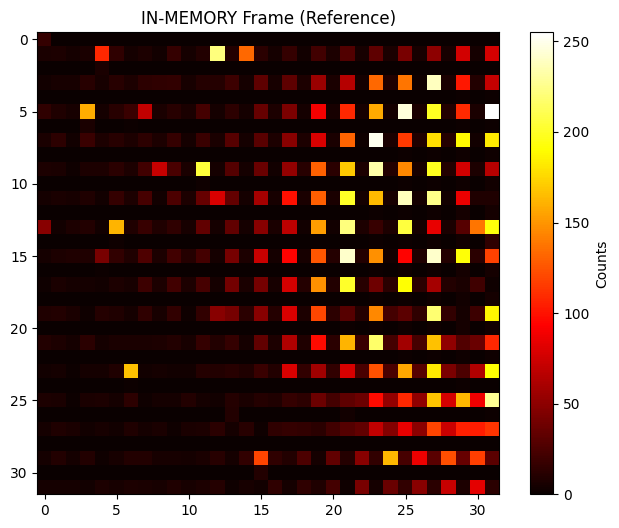

In [4]:
# Display in-memory frame
plt.figure(figsize=(8, 6))
plt.imshow(frame_in_memory, cmap='hot')
plt.colorbar(label='Counts')
plt.title('IN-MEMORY Frame (Reference)')
plt.show()

## 3. Save to .spc3 File

In [5]:
# Save frames to test file
temp_dir = r"C:\Users\SPUD1\Documents\SPAD\images\testing_qudi_img_acq_lizzie"
temp_file = os.path.join(temp_dir, "test_load_fix.spc3")

success = camera_logic.save_frames_to_file(frames_cropped, temp_file)
if success:
    print(f"✓ Saved to: {temp_file}")
    print(f"  File size: {os.path.getsize(temp_file)} bytes")
else:
    print("✗ ERROR: Failed to save file")

✓ Saved to: C:\Users\SPUD1\Documents\SPAD\images\testing_qudi_img_acq_lizzie\test_load_fix.spc3
  File size: 3080 bytes


## 4. Load with ORIGINAL Function (Shows Bug)

In [6]:
# Load with original function
print("Loading with ORIGINAL function (has bug)...")
frames_original, header_original = camera_hardware.read_spc3_file(temp_file)
frame_original = frames_original[0, 0, :, :]

print(f"\nORIGINAL LOAD:")
print(f"  Uses N_pix from header = {header_original.N_pix}")
print(f"  Frame shape: {frame_original.shape}")
print(f"  Min: {frame_original.min()}, Max: {frame_original.max()}, Mean: {frame_original.mean():.1f}")

Loading with ORIGINAL function (has bug)...

ORIGINAL LOAD:
  Uses N_pix from header = 1024
  Frame shape: (32, 32)
  Min: 0, Max: 4094, Mean: 112.9


## 5. Load with CORRECTED Function (Shows Fix)

In [7]:
# Load with corrected function
print("Loading with CORRECTED function (uses N_rows × N_cols)...")
frames_corrected, header_corrected = camera_hardware.spc3.ReadSPC3DataFile_Corrected(temp_file)
frame_corrected = frames_corrected[0, 0, :, :]

print(f"\nCORRECTED LOAD:")
print(f"  Uses N_rows × N_cols = {header_corrected.N_rows} × {header_corrected.N_cols} = {header_corrected.N_rows * header_corrected.N_cols}")
print(f"  Frame shape: {frame_corrected.shape}")
print(f"  Min: {frame_corrected.min()}, Max: {frame_corrected.max()}, Mean: {frame_corrected.mean():.1f}")

Loading with CORRECTED function (uses N_rows × N_cols)...


AttributeError: 'SPC3' object has no attribute 'ReadSPC3DataFile_Corrected'

========= Remote Traceback (1) =========
Traceback (most recent call last):
  File "C:\Users\SPUD1\Documents\experiment_workspace\experiment-main\.venv\lib\site-packages\rpyc\core\protocol.py", line 359, in _dispatch_request
    res = self._HANDLERS[handler](self, *args)
  File "C:\Users\SPUD1\Documents\experiment_workspace\experiment-main\.venv\lib\site-packages\rpyc\core\protocol.py", line 853, in _handle_getattr
    return self._access_attr(obj, name, (), "_rpyc_getattr", "allow_getattr", getattr)
  File "C:\Users\SPUD1\Documents\experiment_workspace\experiment-main\.venv\lib\site-packages\rpyc\core\protocol.py", line 781, in _access_attr
    return accessor(obj, name, *args)
AttributeError: 'SPC3' object has no attribute 'ReadSPC3DataFile_Corrected'


## 6. Diagnostic Comparison

In [ ]:
# Convert to local numpy arrays for comparison
frame_in_memory_local = np.array(frame_in_memory)
frame_original_local = np.array(frame_original)
frame_corrected_local = np.array(frame_corrected)

# Run diagnostics
print("="*70)
print("DIAGNOSTIC: Original Load vs In-Memory")
print("="*70)
camera_hardware.diagnose_buffer_comparison(frame_in_memory_local, frame_original_local)

print("\n" + "="*70)
print("DIAGNOSTIC: Corrected Load vs In-Memory")
print("="*70)
camera_hardware.diagnose_buffer_comparison(frame_in_memory_local, frame_corrected_local)

## 7. Visual Comparison

In [ ]:
# Three-panel comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# In-memory (reference)
im1 = axes[0].imshow(frame_in_memory_local, cmap='hot')
axes[0].set_title('IN-MEMORY\n(Snap Acquisition - Reference)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'Shape: {frame_in_memory_local.shape}')
plt.colorbar(im1, ax=axes[0], label='Counts')

# Original load (broken)
im2 = axes[1].imshow(frame_original_local, cmap='hot')
axes[1].set_title('ORIGINAL LOAD\n(Bug - uses N_pix=0)', fontsize=12, fontweight='bold', color='red')
axes[1].set_xlabel(f'Shape: {frame_original_local.shape}')
plt.colorbar(im2, ax=axes[1], label='Counts')

# Corrected load (fixed)
im3 = axes[2].imshow(frame_corrected_local, cmap='hot')
axes[2].set_title('CORRECTED LOAD\n(Fix - uses N_rows×N_cols)', fontsize=12, fontweight='bold', color='green')
axes[2].set_xlabel(f'Shape: {frame_corrected_local.shape}')
plt.colorbar(im3, ax=axes[2], label='Counts')

plt.tight_layout()
plt.show()

print("\nVISUAL CHECK:")
print("  • Left: What you see during snap acquisition (CORRECT)")
print("  • Middle: What you currently see loading .spc3 files (BROKEN - scrambled data)")
print("  • Right: What you SHOULD see loading .spc3 files (FIXED)")
print("\n✓ If Right matches Left → Fix works correctly!")

## 8. Pixel-Level Verification

In [ ]:
# Check if corrected version matches in-memory pixel-perfect
print("PIXEL-LEVEL COMPARISON:\n")

# Original vs In-Memory
if np.array_equal(frame_in_memory_local, frame_original_local):
    print("Original Load: ✓ MATCHES in-memory (unexpected!)")
else:
    diff_orig = np.abs(frame_in_memory_local.astype(float) - frame_original_local.astype(float))
    print(f"Original Load: ✗ DIFFERS from in-memory")
    print(f"  Max difference: {diff_orig.max()}")
    print(f"  Mean difference: {diff_orig.mean():.2f}")
    print(f"  Different pixels: {(diff_orig > 0).sum()} / {diff_orig.size} ({100*(diff_orig > 0).sum()/diff_orig.size:.1f}%)")

print()

# Corrected vs In-Memory
if np.array_equal(frame_in_memory_local, frame_corrected_local):
    print("Corrected Load: ✓ PIXEL-PERFECT MATCH with in-memory! Fix works! 🎉")
else:
    diff_corr = np.abs(frame_in_memory_local.astype(float) - frame_corrected_local.astype(float))
    print(f"Corrected Load: ⚠ Still differs from in-memory")
    print(f"  Max difference: {diff_corr.max()}")
    print(f"  Mean difference: {diff_corr.mean():.2f}")
    print(f"  Different pixels: {(diff_corr > 0).sum()} / {diff_corr.size} ({100*(diff_corr > 0).sum()/diff_corr.size:.1f}%)")

## 9. Cleanup

In [ ]:
# Remove test file
if os.path.exists(temp_file):
    os.remove(temp_file)
    print(f"✓ Cleaned up: {temp_file}")
else:
    print(f"File not found: {temp_file}")

---

## Summary

**Expected Results:**
- Original load should show scrambled/incorrect data
- Corrected load should match in-memory frame pixel-perfect

**Next Steps:**
1. If corrected version works, update `load_acquisition_file()` to use `read_spc3_file_corrected()` by default
2. Or replace `ReadSPC3DataFile()` with the corrected logic
3. Test in GUI to confirm .spc3 files load and display correctly